

# Homework Deep Learning - Rémi Rousset, Ken Zou, 142


# INTRODUCTION to PyTorch

This notebook provides a simple introduction to pytorch, assuming you already know **Python, NumPy** and how to use **Jupyter/Colab** notebooks.

**PyTorch** is a Python library designed for **deep learning**. All calculations rely on one type of a fundamental data structure: the **tensor**. A tensor is a generalization of vectors (1 dimension) and matrices (2 dimensions) to higher dimensions. For instance:

- A set of matrices with the same dimensions forms a 3-dimensional tensor.
- A colored image consists of 3 matrices (one per chanel: red, blue green), making it a tensor.
- A set of images with the same resolution forms a tensor with 4 dimensions

In deep learning everything is represented as tensors: the input data, model parameters, loss functions, gradients, etc. All computations involve operations on tensors, which makes PyTorch very powerful and flexible library for machine learning.


Machine learning basically relies on three key components:

- **The model:** in this course, the model is a Neural Network, which is represented in pytorch as a **Module**.
- **The loss function:** the model is trained to minimize a loss function, which measures how well it performs.
- **The optimizer:** minimization of the loss function is achieved with gradient descent (or one of its variants) using an **optimizer**.

Moreover, to perform gradient descent, we need to compute the gradient of the loss with respect to the model’s parameters. This is the goal of the so-called **auto-differentiation** which provides efficient computation of these gradients.

In this notbook we will introduce these 3 components, along with PyTorch's basic data structure (the tensors) and the concept of auto-differentiation.


To start with pytorch, here are some external websites:
- http://pytorch.org/tutorials/ : official tutorials
- http://pytorch.org/docs/master/ : official documentation

Before you start, check the version of pytorch!

In [ ]:
import torch as th
print(th.__version__)
import matplotlib.pyplot as plt
import torch.nn as nn

2.6.0+cu124


**You should have a version of at least 1.0.0.**


In [ ]:
# Need help ?
help(th.arange)


Help on built-in function arange in module torch:

arange(...)
    arange(start=0, end, step=1, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False) -> Tensor
    
    Returns a 1-D tensor of size :math:`\left\lceil \frac{\text{end} - \text{start}}{\text{step}} \right\rceil`
    with values from the interval ``[start, end)`` taken with common difference
    :attr:`step` beginning from `start`.
    
    Note: When using floating-point dtypes (especially reduced precision types like ``bfloat16``),
    the results may be affected by floating-point rounding behavior. Some values in the sequence
    might not be exactly representable in certain floating-point formats, which can lead to
    repeated values or unexpected rounding. For precise sequences, it is recommended to use
    integer dtypes instead of floating-point dtypes.
    
    Note that non-integer :attr:`step` is subject to floating point rounding errors when
    comparing against :attr:`end`; to avoid

In [ ]:
# or
?th.arange

# Tensors

In NumPy or MATLAB, you have several methods to create arrays: `zeros`, `ones`, `arange`, `rand`, `randn`... PyTorch uses analogous functions for creating and manipulating tensors, which you will learn how to use. By using these functions, you can easily create tensors and perform various operations on them. For example, PyTorch offers `torch.zeros`, `torch.ones`, `torch.arange`, `torch.rand`, and `torch.randn` to help you initialize tensors in a manner similar to NumPy or MATLAB.



## 1) Operation and access

### **Do the following:**

- Create a Tensor:

        Build a tensor with dimensions 3×4 that is filled with the numbers from 1 to 12.

- Extract Rows and Columns:

        Extract the first row and the last row of the tensor you built.

        Similarly, extract the first column and the last column.

- Matrix Operations with Random Initialization:

        Create matrix A with dimensions 2×3.

        Create matrix B with dimensions 2×1.

        Create matrix C with dimensions 1×4.

        Concatenate matrices A and B (think about the compatibility of the dimensions!!).

        Add the resulting matrix to C.

- Row Selection:

        Create matrix A with dimensions 5×4.

        Create matrix B with dimensions 3×4, such that B is composed of rows from A in this order: the second row, the first row, and the fourth row.

In [ ]:
# We create a tensor 3x4
t = th.arange(1,13).reshape(3, 4)
print(t)

tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])


In [ ]:
# We then extract Rows and Columns
first_row = t[0]
print("The first row is the",first_row)
last_row = t[-1]
print("The last row is the", last_row)
first_column = t[:,0]
print("The first column is the", first_column)
last_column = t[:,-1]
print("The last column is the", last_column)

The first row is the tensor([1, 2, 3, 4])
The last row is the tensor([ 9, 10, 11, 12])
The first column is the tensor([1, 5, 9])
The last column is the tensor([ 4,  8, 12])


In [ ]:
# Matrix Operations with Random Initialization

A = th.ones(2, 3) # 2x3 dimensions
print("A is the", A)
B = th.ones(2, 1) # 2x1 dimensions
print("B is the", B)
C = th.ones(1,4) # 1x4 dimensions
print("C is the", C)

conc = th.cat((A, B), dim=1) # We concatenate A and B, as they are 2-dimensional tensors, meaning their dimensions are 0 and 1.
print("AB is the", conc)

result = conc + C # Adding C to the concatenation AB
print("ABC is the", result)

A is the tensor([[1., 1., 1.],
        [1., 1., 1.]])
B is the tensor([[1.],
        [1.]])
C is the tensor([[1., 1., 1., 1.]])
AB is the tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])
ABC is the tensor([[2., 2., 2., 2.],
        [2., 2., 2., 2.]])


In [ ]:
# Row Selection

A = th.randint(0, 10, size=(5, 4))
print("A is", A)

B = th.stack([A[1], A[0], A[3]])
print("B is", B)

A is tensor([[8, 2, 4, 1],
        [4, 3, 5, 2],
        [2, 8, 9, 4],
        [2, 8, 3, 4],
        [6, 6, 5, 6]])
B is tensor([[4, 3, 5, 2],
        [8, 2, 4, 1],
        [2, 8, 3, 4]])


Look at the following code and how  x2 is built from x. Look at the dimensions of the created tensors.

In [ ]:
x = th.randn(5, 4) # Creating a 2D tensor (5, 4) of random values.
print(x)

x2= th.stack((x,x) , dim=0) # Stacking the two same tensors along a new dimension.
print (x2[0])
print (x2.size())

x2= th.stack((x,x) , dim=1) # The new dimension lies between existing dimensions.
print (x2[0])
print (x2.size())

x2= th.stack((x,x) , dim=2) # The new dimension is at the end.
print (x2[0])
print (x2.size())

tensor([[-0.6062,  0.4771,  0.7203, -0.0215],
        [-0.5757,  1.0949,  1.1196,  0.1306],
        [-0.2589,  1.3113, -0.0360,  0.2118],
        [-0.0730, -1.0638, -0.3050,  0.1267],
        [ 1.6921, -1.0944, -1.0197, -0.5399]])
tensor([[-0.6062,  0.4771,  0.7203, -0.0215],
        [-0.5757,  1.0949,  1.1196,  0.1306],
        [-0.2589,  1.3113, -0.0360,  0.2118],
        [-0.0730, -1.0638, -0.3050,  0.1267],
        [ 1.6921, -1.0944, -1.0197, -0.5399]])
torch.Size([2, 5, 4])
tensor([[-0.6062,  0.4771,  0.7203, -0.0215],
        [-0.6062,  0.4771,  0.7203, -0.0215]])
torch.Size([5, 2, 4])
tensor([[-0.6062, -0.6062],
        [ 0.4771,  0.4771],
        [ 0.7203,  0.7203],
        [-0.0215, -0.0215]])
torch.Size([5, 4, 2])


To understand what stacking means, let's take a simple matrix :
$$A =
  \left[ {\begin{array}{cc}
   1 & 2 \\
   3 & 4 \\
  \end{array} } \right]
$$

In [ ]:
# torch.stack((x, x), dim=0) stacks entire tensors :
[
 [[1, 2],
  [3, 4]],

 [[1, 2],   # copy of the entire matrix
  [3, 4]],
]

# torch.stack((x, x), dim=1) stacks each row with its copy :
[
 [[1, 2],
  [1, 2]], # copy

 [[3, 4],
  [3, 4]],
]

# torch.stack((x, x), dim=2) stacks each value :
[
 [[[1, 1], [2, 2]],
  [[3, 3], [4, 4]]],
]

[[[[1, 1], [2, 2]], [[3, 3], [4, 4]]]]

## 2) Reshape and squeeze

The method `view()` is similar to `reshape` from NumPy. This is **important** since with neural nets, you will often need to manipulate dimensions.

### **Do the following:**

- Build a tensor with dimensions (2, 3, 4).

- Reshape this tensor into two matrices:
    
        One with dimensions (3, 8).
        Another with dimensions (2, 12).

- What does  `view(2,-1)`  do ?

In [ ]:
T = th.randn(2,3,4)
print("T is the", T)

# Reshaping with dimensions (3, 8)
T1 = T.view(3,8)
print("T.view(3,8):",T1)
print(T1.shape)

# Reshaping with dimensions (2, 12)
T2 = T.view(2,12)
print("T.view(2,12):",T2)
print(T2.shape)

# Reshaping with dimensions (2, -1)
T3 = T.view(2,-1)
print("T.view(2,-1):", T3)
print(T3.shape)

T is the tensor([[[ 0.7594,  1.3026, -0.4288,  0.1164],
         [ 1.1851,  0.2386,  0.1411, -1.3354],
         [ 0.0266, -0.9221,  0.7034, -0.3659]],

        [[-0.1965,  1.7250, -0.0934,  2.7436],
         [ 0.3441,  0.2271, -0.4597, -0.6183],
         [ 0.2461,  1.2119,  0.3171, -1.9243]]])
T.view(3,8): tensor([[ 0.7594,  1.3026, -0.4288,  0.1164,  1.1851,  0.2386,  0.1411, -1.3354],
        [ 0.0266, -0.9221,  0.7034, -0.3659, -0.1965,  1.7250, -0.0934,  2.7436],
        [ 0.3441,  0.2271, -0.4597, -0.6183,  0.2461,  1.2119,  0.3171, -1.9243]])
torch.Size([3, 8])
T.view(2,12): tensor([[ 0.7594,  1.3026, -0.4288,  0.1164,  1.1851,  0.2386,  0.1411, -1.3354,
          0.0266, -0.9221,  0.7034, -0.3659],
        [-0.1965,  1.7250, -0.0934,  2.7436,  0.3441,  0.2271, -0.4597, -0.6183,
          0.2461,  1.2119,  0.3171, -1.9243]])
torch.Size([2, 12])
T.view(2,-1): tensor([[ 0.7594,  1.3026, -0.4288,  0.1164,  1.1851,  0.2386,  0.1411, -1.3354,
          0.0266, -0.9221,  0.7034, -0.365

`T.view(2, -1)` seems equivalent to `T.view(2, 12)`. In fact, -1 lets PyTorch to adjust the dimensions based on the total number of elements. As we specified 2 rows and the total number of elements is 24, PyTorch automatically shapes (2, 12).

Assume you have a Tensor A of dimensions (3,2,1) that you initialized as you want.

### **Do the following:**

- Read the documentation of the method `squeeze`.

- Try it on A.

- Try the reverse with `unsqueeze`.

In [ ]:
help(th.squeeze)

Help on built-in function squeeze in module torch:

squeeze(...)
    squeeze(input: Tensor, dim: Optional[Union[int, List[int]]]) -> Tensor
    
    Returns a tensor with all specified dimensions of :attr:`input` of size `1` removed.
    
    For example, if `input` is of shape:
    :math:`(A \times 1 \times B \times C \times 1 \times D)` then the `input.squeeze()`
    will be of shape: :math:`(A \times B \times C \times D)`.
    
    When :attr:`dim` is given, a squeeze operation is done only in the given
    dimension(s). If `input` is of shape: :math:`(A \times 1 \times B)`,
    ``squeeze(input, 0)`` leaves the tensor unchanged, but ``squeeze(input, 1)``
    will squeeze the tensor to the shape :math:`(A \times B)`.
    
    .. note:: The returned tensor shares the storage with the input tensor,
              so changing the contents of one will change the contents of the other.
    
    .. warning:: If the tensor has a batch dimension of size 1, then `squeeze(input)`
              

In [ ]:
A = th.randn(3,2,1)
print("A is the", A)

B = A.squeeze()
print("After squeeze :", B) # It removes the last dimension (size 1) and the new shape is (3, 2)
print(B.shape)

C = B.unsqueeze(2) # Adding a dimension at index 2
print("After unsqueeze :", C)
print(C.shape)

A is the tensor([[[-0.8615],
         [ 0.0566]],

        [[-2.1404],
         [-1.4833]],

        [[-0.6314],
         [ 1.0407]]])
After squeeze : tensor([[-0.8615,  0.0566],
        [-2.1404, -1.4833],
        [-0.6314,  1.0407]])
torch.Size([3, 2])
After unsqueeze : tensor([[[-0.8615],
         [ 0.0566]],

        [[-2.1404],
         [-1.4833]],

        [[-0.6314],
         [ 1.0407]]])
torch.Size([3, 2, 1])


## 3) Automatic differentiation  (auto-grad)

`torch.autograd` provides classes and functions implementing automatic differentiation.
When a tensor is created with `requires_grad=True`, the object will be able to store information about

- *who has created it,*
- *the gradient, if in the future we decide to compute the gradients of some scalar function.*

In the following example, we build a computational graph. The "end" of this graph must be a scalar for automatic differentiation. Look at the following code.



In [ ]:
x = th.randn(1, 1, requires_grad=True)
print("x:",x)
print("x.grad:",x.grad)

x: tensor([[0.8615]], requires_grad=True)
x.grad: None


This tensor `x` has an attribute `grad`, which is initially set to `None`. When you perform operations on `x` using PyTorch functions, a computational graph is being built automatically! This graph keeps track of all operations performed on x and any subsequent tensors derived from it.

The function `backward()` can be called on a tensor that contains a scalar. This call computes the gradients (partial derivatives) of the scalar value with respect to all the tensors that were involved in its computation. Look at the following code:


In [ ]:
y = 2*x+1
print(y)
y.backward() # Calculates the derivative of y(x)
print(x.grad)
x.grad = None

tensor([[2.7230]], grad_fn=<AddBackward0>)
tensor([[2.]])


### **Question:**
*Do you agree with the result ?* (check yourself)

Yes,
x.grad gives the gradient of $y$ with respect to $x$ which is $dy/dx = 2$. However, we have to be careful because if we don't clear .grad after each calculation of the gradient, it keeps adding the gradients. So `x.grad = None` is mandatory to have the correct gradient with respect to the given function $y(x)$.

The computational graph can of course be deeper. For instance, we can introduce a new variable `w`, that is a tensor as well.

In [ ]:
w = th.randn(1,1, requires_grad=True)
x = th.randn(1, 1, requires_grad=True)

print("w=",w.item()," and x=",x.item())

w= 0.0442144013941288  and x= 1.2889230251312256


In [ ]:
z = w*x
z.backward()
print(x.grad)
print(w.grad)
x.grad = None
w.grad = None

tensor([[0.0442]])
tensor([[1.2889]])


### **Question:**

*What do you think about the result ?*

x.grad gives $dz/dx = w$ and y.grad gives $dz/dw = x$, that seems correct. We understand that the variable before .grad is the variable by which the derivate is computed (concept of partial derivative). Once again, clearing .grad each time the derivative is calculated is necessary.


It is worth noticing that the gradient is a tensor operation on a scalar value: **we compute the partial derivative of a scalar quantity w.r.t a tensor**. The variable on which we run the `backward()` method must be a scalar.


### **Question:**

Consider the following code: can you explain the results ?

In [ ]:
x = th.randn(2,2,requires_grad=True)        # x is a square matrix
print(x)
out = 0.5*x.pow(2).sum() # out is a new variable (scalar)
out.backward()           # back propagation in the graph
print("g:",x.grad)       # the gradient of out with respect to x
print("x:",x)            # A simple check. Is it what expected ?

tensor([[-1.3267, -1.7235],
        [ 0.2644,  0.2309]], requires_grad=True)
g: tensor([[-1.3267, -1.7235],
        [ 0.2644,  0.2309]])
x: tensor([[-1.3267, -1.7235],
        [ 0.2644,  0.2309]], requires_grad=True)


We have
$$
x.\text{grad} = \left( \frac{\partial \text{out}}{\partial x_{11}}, \frac{\partial \text{out}}{\partial x_{12}}, \frac{\partial \text{out}}{\partial x_{21}}, \frac{\partial \text{out}}{\partial x_{22}} \right)
$$
and
$$
\frac{d(out)}{dx} = \frac{1}{2} \frac{d(x^2)}{dx} = x \implies \frac{1}{2} \frac{d(x_{ij}^2)}{dx_{ij}} = x_{ij}
$$
Therefore,
$$
x.\text{grad} = \left( \frac{\partial \text{out}}{\partial x_{11}}, \frac{\partial \text{out}}{\partial x_{12}}, \frac{\partial \text{out}}{\partial x_{21}}, \frac{\partial \text{out}}{\partial x_{22}} \right)
= (x_{11}, x_{12}, x_{21}, x_{22}) = x,
$$
so we get
$$x.\text{grad}=x$$



### **Question:**

And can you explain this example  ?

In [ ]:
x = th.randn(2,2,requires_grad=True)        # x is a square matrix
print(x)
w = th.ones(1,2,requires_grad=True)
print(w)
out = 0.5*(w@x).pow(2).sum() # out is a new variable (scalar)
out.backward()           # back propagation in the graph
print("x:",x)
print("x.grad:",x.grad)  # the gradient of out with respect to x
print("w:",w)
print("w.grad:",w.grad)  # the gradient of out with respect to x

tensor([[-0.3054,  0.7087],
        [-0.6373, -1.1119]], requires_grad=True)
tensor([[1., 1.]], requires_grad=True)
x: tensor([[-0.3054,  0.7087],
        [-0.6373, -1.1119]], requires_grad=True)
x.grad: tensor([[-0.9427, -0.4033],
        [-0.9427, -0.4033]])
w: tensor([[1., 1.]], requires_grad=True)
w.grad: tensor([[0.0021, 1.0491]])


`w@x` is a matrix multiplication (1×2). If we introduce :
$$x = \left[ {\begin{array}{cc}
   x_{11} & x_{12} \\
   x_{21} & x_{22} \\
  \end{array} } \right],\quad w = \left[ {\begin{array}{cc}
   w_1 & w_2 \\
  \end{array} } \right]$$
then we get a row vector :
$$w @ x = [w_1 x_{11}+ w_2 x_{21}, w_1 x_{12}+w_2x_{22}]$$
Therefore,
$$out = 0.5\left[(w_1 x_{11}+ w_2 x_{21})^2 + (w_1 x_{12}+w_2x_{22})^2\right]$$
Therefore,
$$
\frac{\partial \text{out}}{\partial x_{11}} = w_1(w_1x_{11}+w_2x_{21})
$$
$$
\frac{\partial \text{out}}{\partial x_{12}} = w_1(w_1x_{12}+w_2x_{22})
$$
$$
\frac{\partial \text{out}}{\partial x_{21}} = w_2(w_1x_{11}+w_2x_{21})
$$
$$
\frac{\partial \text{out}}{\partial x_{22}} = w_2(w_1x_{12}+w_2x_{22})
$$
$$
\frac{\partial \text{out}}{\partial w_{1}} = x_{11}(w_1 x_{11}+ w_2 x_{21})+x_{12}(w_1 x_{12}+w_2x_{22})
$$
$$
\frac{\partial \text{out}}{\partial w_{2}} = x_{21}(w_1 x_{11}+ w_2 x_{21})+x_{22}(w_1 x_{12}+w_2x_{22})
$$
Here we don't have the simple equation $\text{grad}(x^2/2) = x$ because we do a matrix multiplication between $w$ and $x$. The partial gradients follows :
$$
\frac{\partial \text{out}}{\partial x} = \left[ {\begin{array}{c}
   w_1 \\
   w_2 \\
  \end{array} } \right] @ w@x = w^t@w@x
$$
$$
\frac{\partial \text{out}}{\partial w} = \left[ {\begin{array}{cc}
   x_{11} & x_{12} \\
   x_{21} & x_{22} \\
  \end{array} } \right]@ (w@x)^t = x@x^t@w^t
$$

## 4) Linear regression with gradient descent

In this section we focus on linear regression, using synthetic data.

The data are generated with the following code:

torch.Size([8])
torch.Size([8])


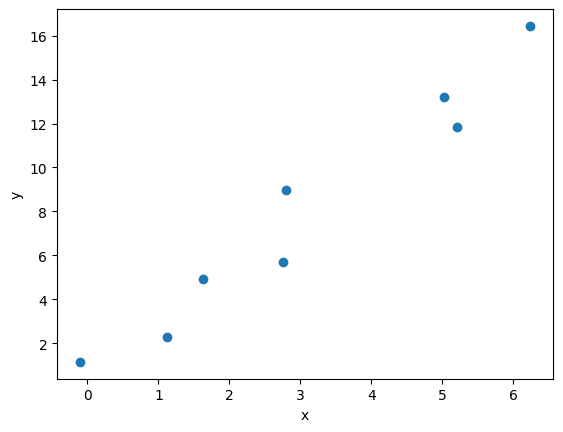

In [ ]:
th.manual_seed(123) # to ensure reproducibility
var= 1 #
X = th.arange(8) + th.randn(8)/var
print(X.size())
Y = 2*(th.arange(8) + th.randn(8)/var) + 0.5
print(Y.size())

_ = plt.scatter(X,Y)

_ = plt.xlabel('x')
_ = plt.ylabel('y')

Our goal is to approximate this simple data set with a function $f$ such that
$$
y_i \approx f(x_i).
$$

To find the right set of parameters that define $f$, we want to minimize the mean square error:
$$L = \frac{1}{N} \sum_i^N (f(x_i) - y_i)^2.$$

Our first assumption is that $f$ is a linear function:
$$ f(x) = w\ x+w_0.$$.

The optimization procedure (here: gradient descent) starts with the random initialization of the parameters $(w,w_0)$.

In [ ]:
w = th.randn(1,requires_grad=True)
w0= th.randn(1,requires_grad=True)

When you plot a linear function $f(x)$ using these randomly chosen parameters $w, w_0$, together with your training points (evaluate the cell belwo), you will see that $f(x)$ does not describe the data very well (or you are very lucky with the random numbers! try again if you are).

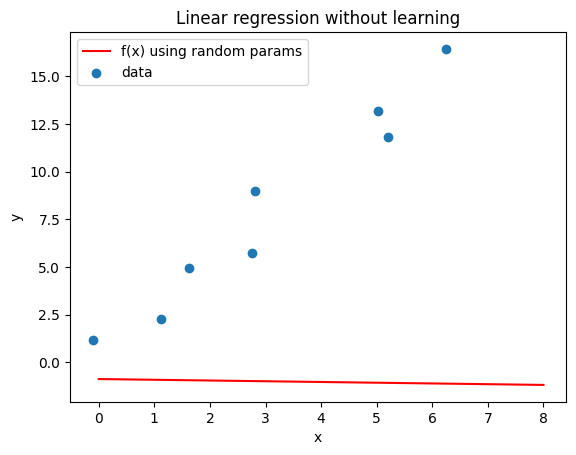

In [ ]:
xs = th.linspace(0,8,2) # need 2 points for a line
plt.plot(xs,(w*xs+w0).detach(),'r', label = 'f(x) using random params')
plt.scatter(X,Y, label = 'data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title("Linear regression without learning")
plt.show()

### **Do the following:**

Quantify the poor quality of this random initialization by computing the loss function.

In [ ]:
## Loss function

# Predicted output
y_mean = w * X + w0

# Mean Squared Error MSE loss
loss = th.mean((y_mean - Y) ** 2)

print("Predicted y :", y_mean)
print("Loss :", loss.item())

Predicted y : tensor([-0.8818, -0.9294, -0.9491, -0.9927, -0.9943, -1.0873, -1.0803, -1.1273],
       grad_fn=<AddBackward0>)
Loss : 109.12237548828125


### **Do the following:**

Use the `backward` function to get the gradient of the loss with respect to the parameters.
- Print the gradients.
- Propose an update of the parameters
- Verify if it improves the loss function

In [ ]:
## Loss function

y_mean = w * X + w0  # Predicted output
loss = th.mean((y_mean - Y) ** 2)
print("Predicted y :", y_mean)
print("Loss :", loss.item())

## Backpropagation
loss.backward()
print("w.grad :", w.grad)
print("w0.grad :", w0.grad)

## Gradient descent
lr = 0.1 # learning rate
w.data = w.data - lr * w.grad  # Update w0
w0.data = w0.data - lr * w0.grad  # Update w0

y_mean_new = w * X + w0
new_loss = th.mean((y_mean_new - Y) ** 2)
print("Updated predicted y :", y_mean_new)
print("Updated Loss :", new_loss.item())

# Better or not ?
if new_loss.item() < loss.item():
    print("The update improved the loss !")
else:
    print("The update did not improve the loss.")

Predicted y : tensor([-0.8818, -0.9294, -0.9491, -0.9927, -0.9943, -1.0873, -1.0803, -1.1273],
       grad_fn=<AddBackward0>)
Loss : 109.12237548828125
w.grad : tensor([-77.0628])
w0.grad : tensor([-18.1409])
Updated predicted y : tensor([ 0.0733,  9.5186, 13.4291, 22.0875, 22.4210, 40.8709, 39.4783, 48.8122],
       grad_fn=<AddBackward0>)
Updated Loss : 394.49713134765625
The update did not improve the loss.


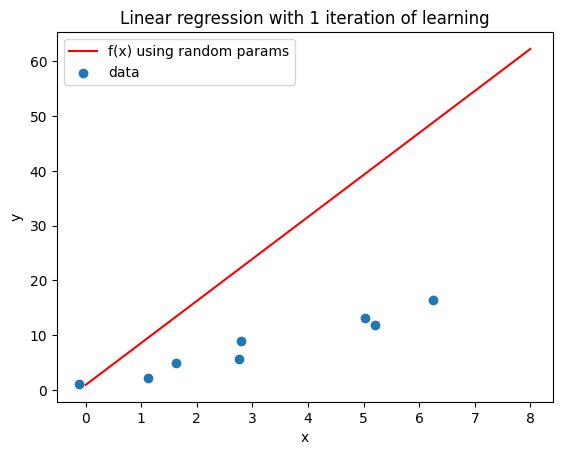

In [ ]:
xs = th.linspace(0,8,2) # need 2 points for a line
plt.plot(xs,(w*xs+w0).detach(),'r', label = 'f(x) using random params')
plt.scatter(X,Y, label = 'data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title("Linear regression with 1 iteration of learning")
plt.show()

It's better sometimes. But sometimes it doesn't work. We have to implement more iterations to be satisfied and for the loss to globally decrease over iterations, otherwise it seems random !

## 5) Optimizer and the loss function

The optimizer "takes care" of model parameters update during training. In PyTorch, the base class for all optimizers is `Optimizer`, which is a part of the module `torch.optim`. As you discussed in TD, one commonly used optmizer is Stochastic Gradient Descent `SGD`. Look at the details in its documentation!

In the future, you will also use `Adam`optimizer, but for the moment we are focusing on `SGD`. Note, however, that they all have (more or less) the same interface --- to create an optimizer instance, you need to pass the parameters to be updated and specify the learning rate (lr).


We continue with our concrete problem: to create an optimizer we start by creating an object `SGD` with:

- the parameters under consideration
- the lr parameter,

(see the code below). The parameters we want to learn are `w` and `w0`.

In [ ]:
w = th.randn(1,requires_grad=True)
w0= th.randn(1,requires_grad=True)
trainable_parameters = (w,w0)
sgd = th.optim.SGD(trainable_parameters, lr=0.01) # Learning rate = 1

### **Do the following:**

- Explain the parameter `lr`.

The learning rate $\eta$ is a scalar value that controls the step size at which a model's parameters are updated during training/learning.
$$W = W - \eta \nabla W$$
It's a parameter that we fix and that determines how much we adjust the parameters by moving in the direction opposite to the gradient to minimize the loss. The learning rate has to be optimized to converge to the minimum by being not too big (no convergence) but also not too small (the algorithm may stop at a local minimum and not the global minimum, or the experiment may simply be too long).



The two important functions you will use are:

- `step()` --- This function updates all trainable parameters using their computed gradients (e.g., w.grad and w0.grad).

- `zero_grad()` --- This function resets the gradient values, preparing them for the next training step.


### **Do the following:**
- Compute Predictions:
        
        Compute the predictions for the input data `X`.

- Backward Propagation:
    
        Do the backpropagation and print the values of `w` and `w0` along with their gradients.

- Update Parameters:
   
        Make an update using the optimizer and print the updated values of `w` and `w0` with their gradients.

- Reset Gradients:
    
        Run `zero_grad()` to reset the gradients and print the values of `w` and `w0` with their gradients after resetting.

- Plot the New Line:
        
        Plot the new line defined by the new values of `w` and `w0`.

- Evaluate Learning Rate:
    
        Do you think value of the learning rate `lr` is adapted for this task ?

Iteration 0, Loss : 135.67941284179688
w : -0.47090014815330505, Gradient : -86.2046127319336
w0 : -0.42690107226371765, Gradient : -19.890073776245117
Iteration 1, Loss : 68.80186462402344
w : 0.3911459743976593, Gradient : -61.09607696533203
w0 : -0.22800034284591675, Gradient : -14.17263126373291
Iteration 2, Loss : 35.19071960449219
w : 1.002106785774231, Gradient : -43.29612731933594
w0 : -0.08627403527498245, Gradient : -10.118972778320312
Iteration 3, Loss : 18.298357009887695
w : 1.4350680112838745, Gradient : -30.677431106567383
w0 : 0.014915689826011658, Gradient : -7.24481201171875
Iteration 4, Loss : 9.808399200439453
w : 1.741842269897461, Gradient : -21.731830596923828
w0 : 0.08736380934715271, Gradient : -5.2068281173706055
Iteration 5, Loss : 5.541267395019531
w : 1.959160566329956, Gradient : -15.390185356140137
w0 : 0.13943208754062653, Gradient : -3.761631727218628
Iteration 6, Loss : 3.3964128494262695
w : 2.1130623817443848, Gradient : -10.894536972045898
w0 : 0.17

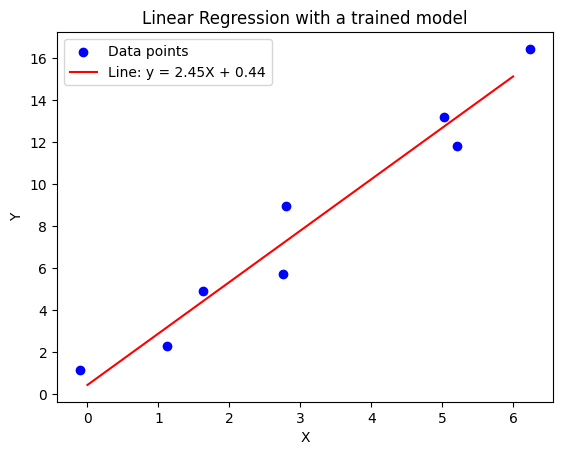

In [ ]:
# Loss function
loss = th.nn.MSELoss()

# Training loop for a few iterations

nb_iterations = 100
for iteration in range(nb_iterations):
    sgd.zero_grad()

    # Compute predictions
    y_pred = w * X + w0

    # Compute loss
    loss_f = loss(y_pred, Y)

    # Backpropagation
    loss_f.backward()

    # Print values of w and w0, and their gradients
    print(f'Iteration {iteration}, Loss : {loss_f.item()}')
    print(f'w : {w.item()}, Gradient : {w.grad.item()}')
    print(f'w0 : {w0.item()}, Gradient : {w0.grad.item()}')

    # Update parameters
    sgd.step()

# Reset gradients and print updated values
print("\nAfter resetting gradients:")
print(f'w : {w.item()}, Gradient : {w.grad.item()}')
print(f'w0 : {w0.item()}, Gradient : {w0.grad.item()}')

# Reset gradients
sgd.zero_grad()

# Parameters update
X_m = th.tensor([[0], [6]])  # Min and max values for X
Y_m = w * X_m + w0  # Get predictions for X values

# Plot the data points
plt.scatter(X.numpy(), Y.numpy(), color='b', label='Data points')
# Plot the new line
plt.plot(X_m.numpy(), Y_m.detach().numpy(), color='r', label=f'Line: y = {w.item():.2f}X + {w0.item():.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Linear Regression with a trained model')
plt.show()


The learning rate `lr` is adapted for this task because the loss decreases regularly. The convergence is fast and the isn't any divergence. The linear regression is satisfying !

Many loss functions are already implemented in PyTorch (see https://pytorch.org/docs/stable/nn.html#loss-functions for the full list). In our lab sessions we will focus on:

- `MSELoss` for regression
- `BCELoss` for binary classification
- `CrossEntropyLoss` and `NLLLoss` for multiclass classification


- Read the documentation of these losses and apply the `MSELoss` to the prediction for `X`
- Repeat all the steps from the previous TODO list and include a calculation of the `MSELoss`.


## 6) The training function

Now you have everything to write the training code of the model!


### **Do the following:**

- Initialize the model parameters before the training begins.

- Perform SGD in a loop: iterate over multiple epochs, updating parameters using the optimizer.

- Record how the loss evolves after each epoch.

- Plot the loss evolution during the training process.

- Plot the new decision boundary and observe how it changed during training.


Epoch 0, Loss : 18.456422805786133
w : 2.3031561374664307, Gradient : -23.31484603881836
w0 : 2.1517770290374756, Gradient : -7.297609806060791
Epoch 1, Loss : 8.58104419708252
w : 0.7725332379341125, Gradient : 15.306228637695312
w0 : 1.5698435306549072, Gradient : 5.819334983825684
Epoch 2, Loss : 4.129814624786377
w : 1.8288116455078125, Gradient : -10.562784194946289
w0 : 1.8696081638336182, Gradient : -2.9976468086242676
Epoch 3, Loss : 2.1149494647979736
w : 1.1507902145385742, Gradient : 6.780214309692383
w0 : 1.5812807083129883, Gradient : 2.8832740783691406
Epoch 4, Loss : 1.1949329376220703
w : 1.6339645385742188, Gradient : -4.831743240356445
w0 : 1.6896294355392456, Gradient : -1.0834875106811523
Epoch 5, Loss : 0.7673910856246948
w : 1.338202953338623, Gradient : 2.957615852355957
w0 : 1.5347212553024292, Gradient : 1.549081802368164
Epoch 6, Loss : 0.5618143081665039
w : 1.563537836074829, Gradient : -2.2533488273620605
w0 : 1.5586755275726318, Gradient : -0.2395424842834

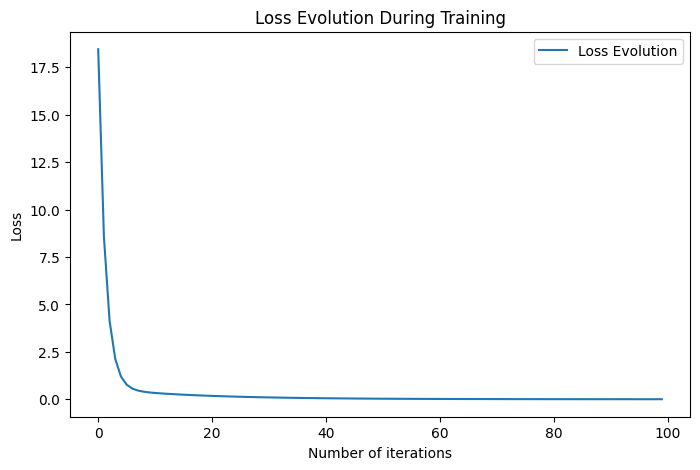

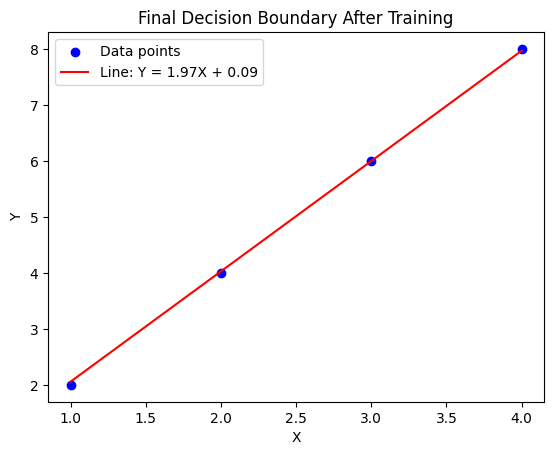

In [ ]:
### Example of a perfect linear data ###

Nepoch = 100
lr = 1e-1 # Learning rate = 0.1

# Initialization
X = th.tensor([[1.0], [2.0], [3.0], [4.0]], requires_grad=False)
Y = th.tensor([[2.0], [4.0], [6.0], [8.0]], requires_grad=False)
w = th.randn(1, requires_grad=True)
w0 = th.randn(1, requires_grad=True)
trainable_parameters = (w,w0)
sgd = th.optim.SGD(trainable_parameters, lr)

# Loss function
loss_function = th.nn.MSELoss()

losses = []

# Training loop for a few epochs
for epoch in range(Nepoch):
    sgd.zero_grad()  # Zero gradients before the backward pass

    # Compute predictions (y_pred = w * X + w0)
    y_pred = w * X + w0

    # Compute loss
    loss = loss_function(y_pred, Y)

    losses.append(loss.item())

    loss.backward()

    # Update parameters
    sgd.step()

    # Print values of w, w0 and the gradients
    print(f'Epoch {epoch}, Loss : {loss.item()}')
    print(f'w : {w.item()}, Gradient : {w.grad.item()}')
    print(f'w0 : {w0.item()}, Gradient : {w0.grad.item()}')

# Loss evolution
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss Evolution')
plt.xlabel('Number of iterations')
plt.ylabel('Loss')
plt.title('Loss Evolution During Training')
plt.legend()
plt.show()

X_m = th.tensor([[1.0], [4.0]])  # Min and max values for X
Y_m = w * X_m + w0  # Get predictions for X values

# Plotting the data points
plt.scatter(X.numpy(), Y.numpy(), color='b', label='Data points')

# Plotting the decision boundary
plt.plot(X_m.numpy(), Y_m.detach().numpy(), color='r', label=f'Line: Y = {w.item():.2f}X + {w0.item():.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Final Decision Boundary After Training')
plt.show()


It is reassuring that the linear regression follows the linear data. Moreover, the loss function decreases over time, which is normal. It decreases fastly (around the fisrt 5 iterations) which is normal because the data are ideal, so that the regression seems easy to get !

Epoch 0, Loss : 0.6399579048156738
w : -0.23566606640815735, Gradient : -0.750827431678772
w0 : 0.05507586896419525, Gradient : 1.506232738494873
Epoch 1, Loss : 0.39010411500930786
w : -0.17963533103466034, Gradient : -0.5603073835372925
w0 : -0.06070327013731003, Gradient : 1.1577913761138916
Epoch 2, Loss : 0.24414777755737305
w : -0.1380344182252884, Gradient : -0.4160091280937195
w0 : -0.14980465173721313, Gradient : 0.8910138607025146
Epoch 3, Loss : 0.15882441401481628
w : -0.10734448581933975, Gradient : -0.3068993091583252
w0 : -0.21847085654735565, Gradient : 0.6866620779037476
Epoch 4, Loss : 0.10889603942632675
w : -0.0848882645368576, Gradient : -0.22456224262714386
w0 : -0.2714747488498688, Gradient : 0.5300388336181641
Epoch 5, Loss : 0.0796385258436203
w : -0.06863023340702057, Gradient : -0.16258031129837036
w0 : -0.3124663233757019, Gradient : 0.4099157154560089
Epoch 6, Loss : 0.062460124492645264
w : -0.057024139910936356, Gradient : -0.11606093496084213
w0 : -0.344

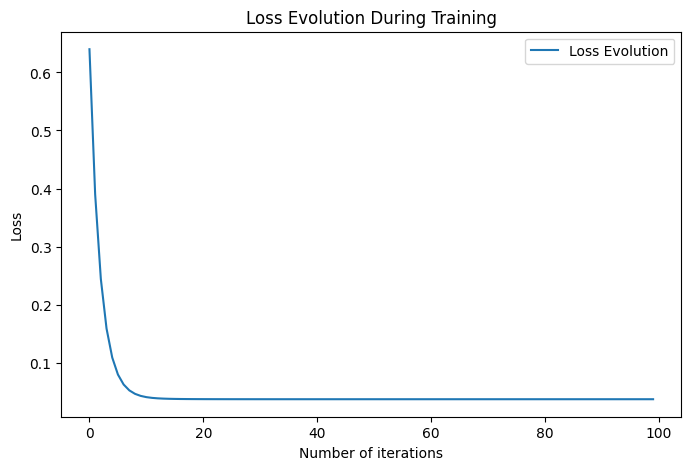

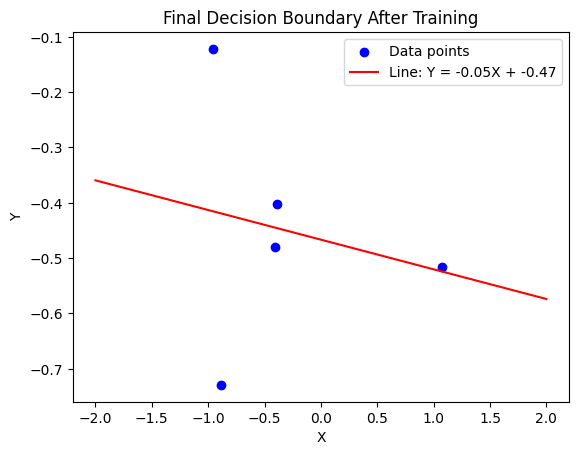

In [ ]:
### Example of a randomized data ###

Nepoch = 100
lr = 1e-1 # Learning rate = 0.1

# Initialization
X = th.randn(5)
Y = th.randn(5)
w = th.randn(1, requires_grad=True)
w0 = th.randn(1, requires_grad=True)
trainable_parameters = (w,w0)
sgd = th.optim.SGD(trainable_parameters, lr)

# Loss function
loss_function = th.nn.MSELoss()

losses = []

for epoch in range(Nepoch):
    sgd.zero_grad()

    # Compute predictions (y_pred = w * X + w0)
    y_pred = w * X + w0

    # Compute loss
    loss = loss_function(y_pred, Y)

    losses.append(loss.item())

    loss.backward()

    # Update parameters
    sgd.step()

    # Print values of w, w0 and the gradients
    print(f'Epoch {epoch}, Loss : {loss.item()}')
    print(f'w : {w.item()}, Gradient : {w.grad.item()}')
    print(f'w0 : {w0.item()}, Gradient : {w0.grad.item()}')


plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss Evolution')
plt.xlabel('Number of iterations')
plt.ylabel('Loss')
plt.title('Loss Evolution During Training')
plt.legend()
plt.show()

X_m = th.tensor([[-2], [2]])  # Min and max values for X
Y_m = w * X_m + w0  # Predictions for X values

# Plotting the data points
plt.scatter(X.numpy(), Y.numpy(), color='b', label='Data points')

# Plotting the decision boundary
plt.plot(X_m.numpy(), Y_m.detach().numpy(), color='r', label=f'Line: Y = {w.item():.2f}X + {w0.item():.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Final Decision Boundary After Training')
plt.show()


With randomized data, the regression is still good and the loss function decreases quite fast too !

## 7) Module

In the previous section we coded our linear model "by hand". In practice, it is more convenient to use existing modules (base class `Module`). For instance the linear transform $f(x) = wx+w_0$ is simply the application of a so-called `Linear` module.

### **Do the following:**

- Look at the documentation

- Rewrite the training code such that it uses a `Linear` module.

- Look at the result.

Epoch 0, Loss : 5.1947712898254395
w : 0.4058431088924408, Gradient : -4.456475734710693
w0 : 0.2287636399269104, Gradient : 1.5206557512283325
Epoch 1, Loss : 3.228023052215576
w : 0.7551023960113525, Gradient : -3.4925930500030518
w0 : 0.1236952617764473, Gradient : 1.0506837368011475
Epoch 2, Loss : 2.04667592048645
w : 1.0293458700180054, Gradient : -2.7424352169036865
w0 : 0.05263770371675491, Gradient : 0.7105755805969238
Epoch 3, Loss : 1.3329499959945679
w : 1.2451118230819702, Gradient : -2.1576590538024902
w0 : 0.005997208412736654, Gradient : 0.4664049446582794
Epoch 4, Loss : 0.8989579677581787
w : 1.4152143001556396, Gradient : -1.7010245323181152
w0 : -0.02328578568994999, Gradient : 0.2928299307823181
Epoch 5, Loss : 0.63319993019104
w : 1.549595832824707, Gradient : -1.3438156843185425
w0 : -0.040382083505392075, Gradient : 0.17096297442913055
Epoch 6, Loss : 0.46922287344932556
w : 1.6559823751449585, Gradient : -1.0638655424118042
w0 : -0.04905832186341286, Gradient :

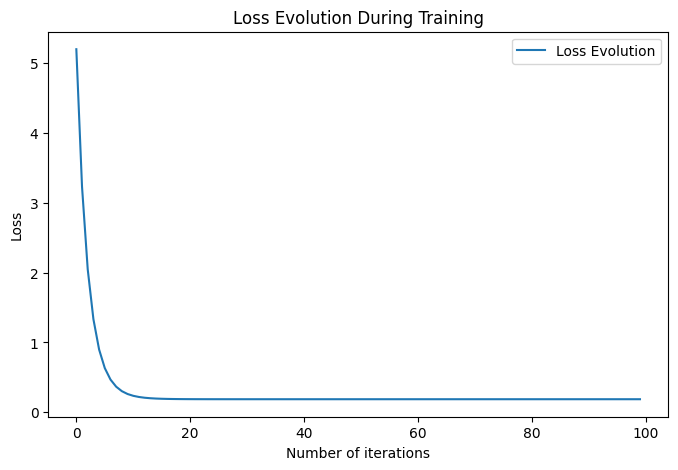

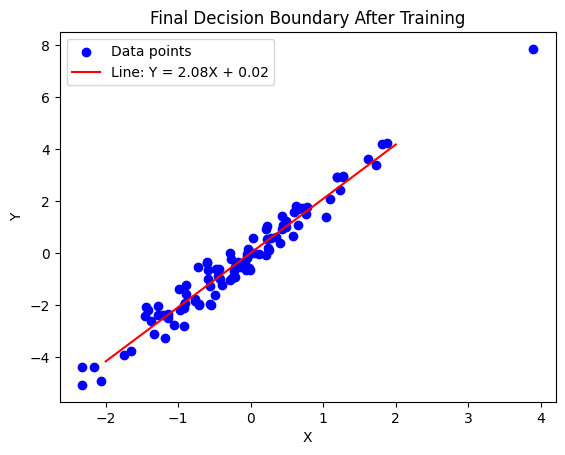

In [ ]:
### Example of linear data with noise ###

Nepoch = 100
lr = 1e-1 # Learning rate = 0.1

# Initialization
X = th.randn(100, 1)
Y = 2 * X + 0.5 * th.randn(100, 1)  # Linear tendency with noise

model = th.nn.Linear(1, 1)

sgd = th.optim.SGD(model.parameters(), lr)

# Loss function
loss_function = th.nn.MSELoss()

losses = []

for epoch in range(Nepoch):
    sgd.zero_grad()

    # Compute predictions (y_pred = model(X))
    y_pred = model(X)

    # Compute loss
    loss = loss_function(y_pred, Y)

    losses.append(loss.item())

    loss.backward()

    # Update parameters
    sgd.step()

    # Print values of w, w0 and the gradients
    print(f'Epoch {epoch}, Loss : {loss.item()}')
    print(f'w : {model.weight.item()}, Gradient : {model.weight.grad.item()}')
    print(f'w0 : {model.bias.item()}, Gradient : {model.bias.grad.item()}')

plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss Evolution')
plt.xlabel('Number of iterations')
plt.ylabel('Loss')
plt.title('Loss Evolution During Training')
plt.legend()
plt.show()

X_m = th.tensor([[-2], [2]], dtype=th.float32)  # Min and max values for X
Y_m = model(X_m) # Predictions for X values

# Plotting the data points
plt.scatter(X.numpy(), Y.numpy(), color='b', label='Data points')

# Plotting the decision boundary
plt.plot(X_m.numpy(), Y_m.detach().numpy(), color='r', label=f'Line: Y = {model.weight.item():.2f}X + {model.bias.item():.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Final Decision Boundary After Training')
plt.show()


## 8) Logistic Regression

Let start with an easy dataset for binary classification. The following subsections just provide a synthetic dataset and a function to visualize it.



### 8.1)  Create the data


In [ ]:
import numpy as np
ST1 = np.array([[17.0 ,12 ,13 ,15 ,15 ,20 ,20],[ 10 ,12 ,14 ,15 ,20 ,15 ,20]]) # class 1
ST2 = np.array([4, 7.5, 10 ,11, 5 ,5 ,6, 8, 5, 0, 5, 0, 10, 6]).reshape(2,7) # class 2
Xstudents = np.concatenate((ST1,ST2),axis=1)
Ystudents = np.ones(14)
Ystudents[7:] = 0


### **Do the following:**

- Plot the dataset with two colors (one for each class).


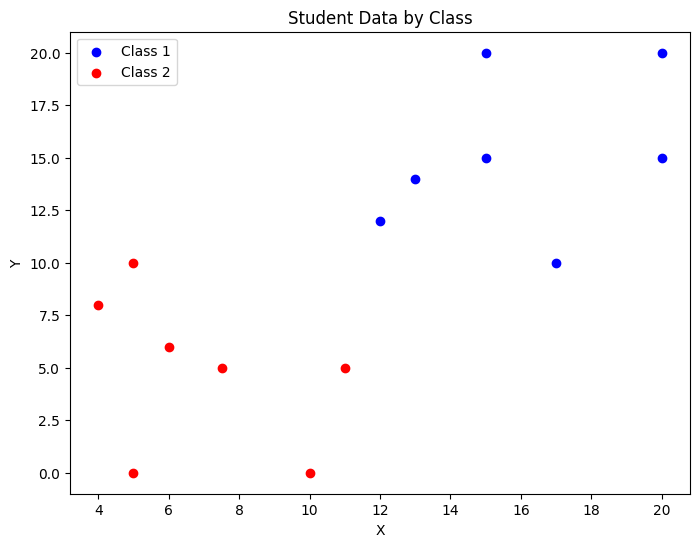

In [ ]:
import matplotlib.pyplot as plt

# Separate by class
class1 = Xstudents[:, Ystudents == 1]
class2 = Xstudents[:, Ystudents == 0]

plt.figure(figsize=(8,6))
plt.scatter(class1[0], class1[1], color='b', label='Class 1')
plt.scatter(class2[0], class2[1], color='r', label='Class 2')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Student Data by Class')
plt.legend()
plt.show()

### 8.2) The model


In this section, you will define, train, and visualize a logistic regression model using PyTorch.


The roadmap is:

- Convert Data to Tensors:

        As explained PyTorch models utilises Tensor objects. Make sure that your dataset is converted into PyTorch tensors before training.

- Create the Logistic Regression Model:

        Use `torch.nn.Sequential` to define a simple neural model. The model should consist of a single neuron with a logistic activation function (i.e., a linear layer followed by a sigmoid function).

- Define the Optimizer:

        Take the basic Stochastic Gradient Descent (SGD) as the optimization algorithm.

- Define the Objective (Loss) Function

- Train the Model:

        Implement a training loop that iterates until convergence. It can be useful to play with different learning rates to observe their effects. Perform gradient descent step-by-step, updating the model parameters after each example.

- Look at the solution:

        Visualize the decision boundary and check how well the model has learned.

- Train in Batch Mode:

        Start again in **batch** mode -- instead of updating the model after each example, compute gradients using the entire training set.


### **Do all the things in the list above**

#### From data to tensors / variables


In [ ]:
# Tensors
X = th.tensor(Xstudents, dtype=th.float32).T
Y = th.tensor(Ystudents, dtype=th.float32).unsqueeze(1)

#### Create the model, its loss and optimizer

The model is a linear transformation followed by a Sigmoid function. This is equivalent to a logistic regression model.

In [ ]:
# The model
D_in=2  # input size : 2
D_out=1 # output size: one value

# Logistic Regression Model
model = th.nn.Sequential(th.nn.Linear(D_in, D_out),th.nn.Sigmoid()) # a single neuron with a logistic activation

# The optimizer
sgd = th.optim.SGD(model.parameters(), lr=0.1)

# The loss
loss_function = th.nn.BCELoss()

#### Testing the model with data
You can run inference to see if everything is fine.


In [ ]:
# With a single input vector
prediction = model(X[0]) # or prediction = model.forward(X[0]) both are equivalent

print("For the first input: ",prediction)

# With 3 input vectors
prediction = model(X[0:3])
print("For the 3 first inputs: ",prediction)

# For the whole dataset
prediction = model(X)
print("For all: ",prediction)

For the first input:  tensor([1.0000], grad_fn=<SigmoidBackward0>)
For the 3 first inputs:  tensor([[1.0000],
        [0.9999],
        [1.0000]], grad_fn=<SigmoidBackward0>)
For all:  tensor([[1.0000],
        [0.9999],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [0.9754],
        [0.9950],
        [0.9974],
        [0.9994],
        [0.9464],
        [0.9906],
        [0.9896]], grad_fn=<SigmoidBackward0>)


The model hasn't been trained enough because half of the data are class 1 and the other half class 2.


In [ ]:
# With a single input vector
prediction = model(X[0])
print("The first prediction: ",prediction, prediction.shape)
print("The reference: ",Y[0], Y[0].shape)

loss_function(prediction,Y[0])

The first prediction:  tensor([1.0000], grad_fn=<SigmoidBackward0>) torch.Size([1])
The reference:  tensor([1.]) torch.Size([1])


tensor(5.8413e-06, grad_fn=<BinaryCrossEntropyBackward0>)

This code should generate a warning or an error, since the label (or target value) and the prediction (considered as the input value of the loss) are of different dimensions.

There is two ways to fix this. The first one is to reduce the input dimension using `squeeze`. The second one is to modify the target values. See the two cells below.

In [ ]:
prediction = model(X[0]).squeeze()
print("The first prediction: ",prediction, prediction.shape)
print("The reference: ",Y[0], Y[0].shape)

loss_function(prediction,Y[0].squeeze())

The first prediction:  tensor(1.0000, grad_fn=<SqueezeBackward0>) torch.Size([])
The reference:  tensor([1.]) torch.Size([1])


tensor(5.8413e-06, grad_fn=<BinaryCrossEntropyBackward0>)

In [ ]:
prediction = model(X[0])
Ymodified = Y.view(-1,1)
print("The first prediction: ",prediction, prediction.shape)
print("The reference: ",Ymodified[0], Ymodified[0].shape)

loss_function(prediction,Ymodified[0])

The first prediction:  tensor([1.0000], grad_fn=<SigmoidBackward0>) torch.Size([1])
The reference:  tensor([1.]) torch.Size([1])


tensor(5.8413e-06, grad_fn=<BinaryCrossEntropyBackward0>)

#### Training loop


In [ ]:
# Training process
losses = []
for epoch in range(500):
    sgd.zero_grad()
    y_pred = model(X)
    loss = loss_function(y_pred, Y)
    losses.append(loss.item())
    loss.backward()
    sgd.step()

It is better to visualize the evolution of the loss function: to be sure that everything went well. The idea is to store the loss values in a numpy array and then to plot it.

####  Plot the solution

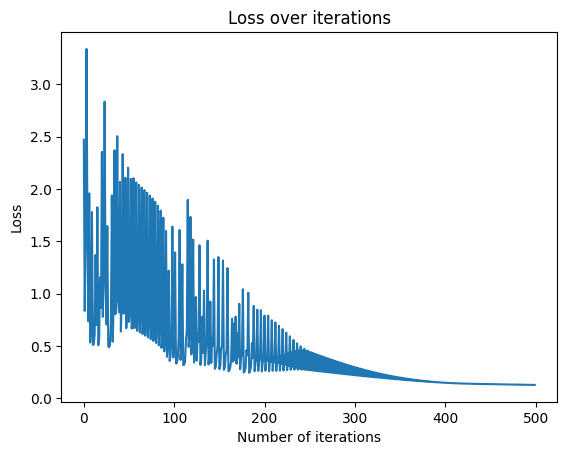

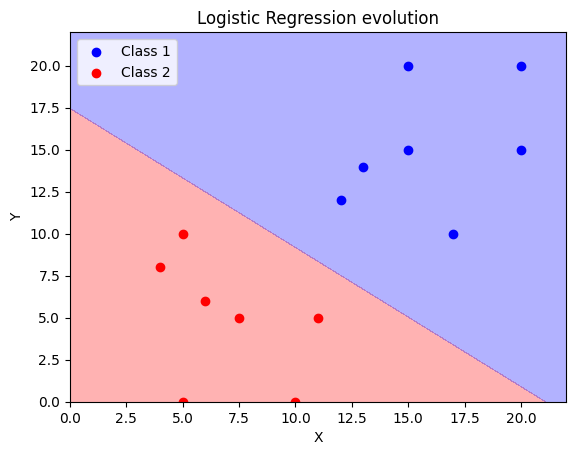

In [ ]:
# Loss visualization
plt.plot(losses)
plt.title("Loss over iterations")
plt.xlabel("Number of iterations")
plt.ylabel("Loss")
plt.show()

# Decision boundary visualization
x1 = np.linspace(0, 22, 100)
x2 = np.linspace(0, 22, 100)
xx1, xx2 = np.meshgrid(x1, x2)
grid = np.stack([xx1.ravel(), xx2.ravel()], axis=1)
grid_tensor = th.tensor(grid, dtype=th.float32)

with th.no_grad():
    preds = model(grid_tensor).reshape(xx1.shape)
plt.contourf(xx1, xx2, preds, levels=[0, 0.5, 1], alpha=0.3, colors=['r', 'b'])

plt.scatter(ST1[0], ST1[1], color='b', label='Class 1')
plt.scatter(ST2[0], ST2[1], color='r', label='Class 2')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Logistic Regression evolution')
plt.legend()
plt.show()

We see that the logistic regression is good and classified the two classes of data points. The loss function decreases over time with oscillations, which are probably due to the fact that after each iteration, the loss function can be closer or farther to the minimum. But globally it decreases, which is good.

#### Explore the "solution"

Here, we look at the different wrapping steps:
- The model is a set of modules
- A Linear module is a matrix of weights along with a bias vector. They are parameters.
- A Parameter wrap a tensor
- A tensor can be casted as a numpy array


In [ ]:
mod = model[0]
print(type(mod))
print(type(mod.bias))
print(type(mod.bias.data))
print(type(mod.bias.data.numpy()))

<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.parameter.Parameter'>
<class 'torch.Tensor'>
<class 'numpy.ndarray'>


We can look at the parameters:

In [ ]:
print(mod.bias.data.view(1,1))
print(mod.weight.data)

tensor([[-4.9934]])
tensor([[0.2368, 0.2860]])


#### Impact of the learning rate

Now, we will use the same model, but trained with a different learning rate. The training process restarts from scratch. We need to therefore re-create the model and the associated optimizer.

In [ ]:
model = th.nn.Sequential(th.nn.Linear(D_in, D_out),th.nn.Sigmoid())
learning_rate = 1e-1
optimizer = th.optim.SGD(model.parameters(), lr=learning_rate)

Now that we have the model, with randomly initialized parameters, we can train it using a different learning rate --- a larger one.

#### **Do the following:**

- Run the training with the same number of epochs and compare the loss value we get at the end
- Do you think we can reach the same value with the learning rate of 1e-2, but with a longer training ?
- Try the same thing with a learning rate of 0.5, what do you observe ?



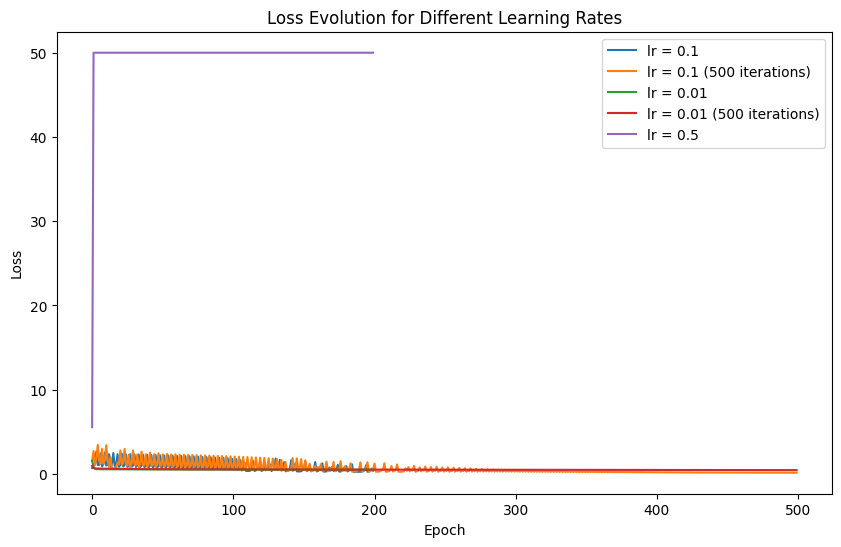

In [ ]:
def logistic_model(lr, epochs=200):
    model = th.nn.Sequential(th.nn.Linear(2, 1),th.nn.Sigmoid())

    optimizer = th.optim.SGD(model.parameters(), lr=lr)
    loss_function = th.nn.BCELoss()

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_function(y_pred, Y)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()

    return losses, model

losses_1, model_1 = logistic_model(lr=0.1)
losses_5, model_5 = logistic_model(lr=0.1,epochs=500)
losses_2, model_2 = logistic_model(lr=0.01)
losses_3, model_3 = logistic_model(lr=0.01, epochs=500)  # longer training
losses_4, model_4 = logistic_model(lr=0.5)


plt.figure(figsize=(10, 6))
plt.plot(losses_1, label='lr = 0.1')
plt.plot(losses_5, label='lr = 0.1 (500 iterations)')
plt.plot(losses_2, label='lr = 0.01')
plt.plot(losses_3, label='lr = 0.01 (500 iterations)')
plt.plot(losses_4, label='lr = 0.5')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Evolution for Different Learning Rates')
plt.legend()
plt.show()

A too big learning rate leads to the fact that the loss function does not converge to the minimum, so that the loss function does not decrease and oscillates between certain values. The more iterations we put, the faster the loss function decreases, considering one learning rate at a time.

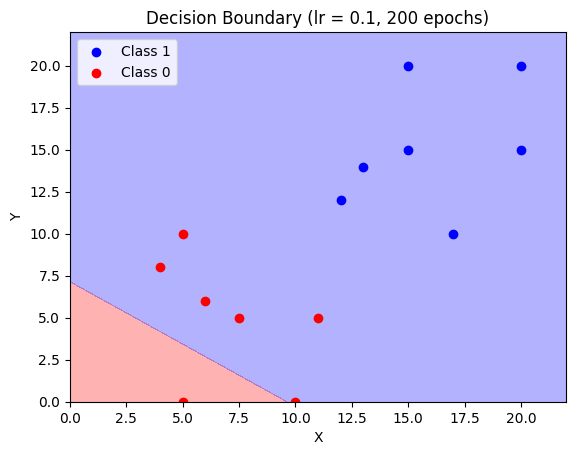

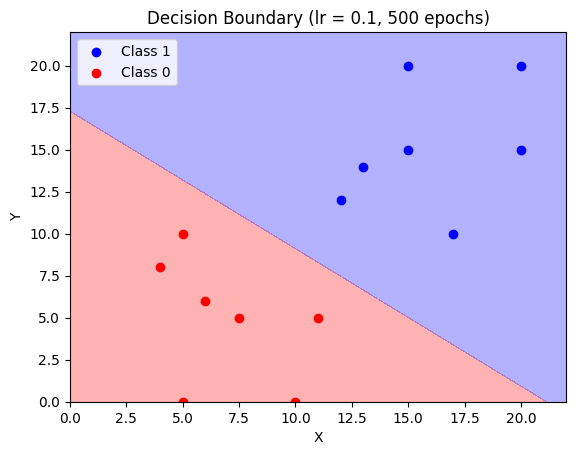

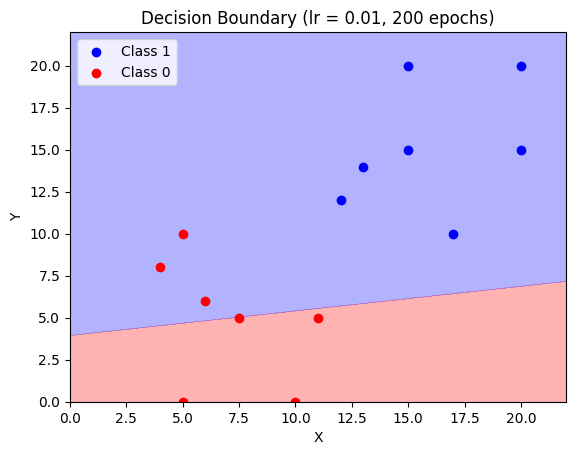

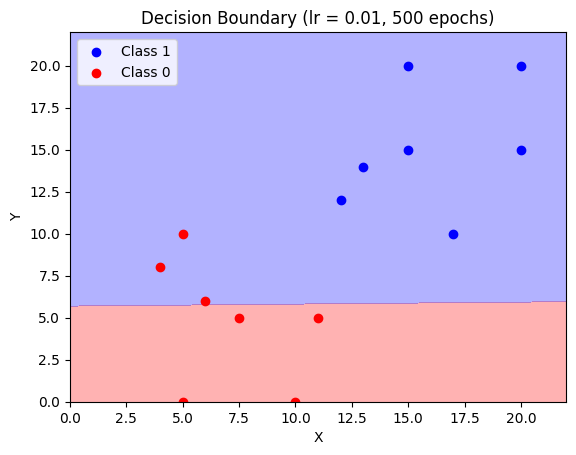

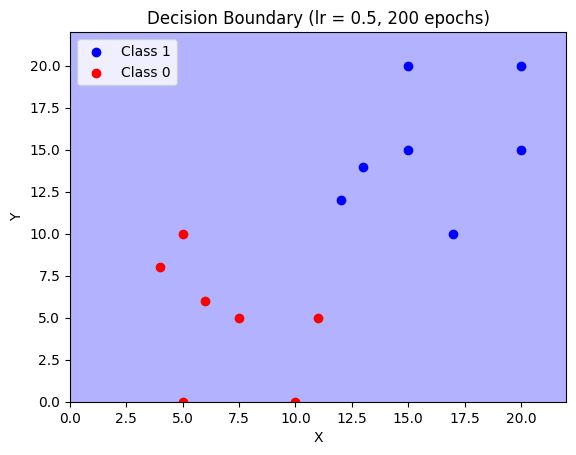

In [ ]:
def decision_boundary(model, title):
    x1 = np.linspace(0, 22, 200)
    x2 = np.linspace(0, 22, 200)
    xx1, xx2 = np.meshgrid(x1, x2)
    grid = np.stack([xx1.ravel(), xx2.ravel()], axis=1)
    grid_tensor = th.tensor(grid, dtype=th.float32)

    with th.no_grad():
        preds = model(grid_tensor).reshape(xx1.shape)

    plt.contourf(xx1, xx2, preds, levels=[0, 0.5, 1], colors=["r", "b"], alpha=0.3)

    plt.scatter(ST1[0], ST1[1], color='b', label='Class 1')
    plt.scatter(ST2[0], ST2[1], color='r', label='Class 0')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(title)
    plt.legend()
    plt.show()


decision_boundary(model_1,  "Decision Boundary (lr = 0.1, 200 epochs)")
decision_boundary(model_5,  "Decision Boundary (lr = 0.1, 500 epochs)")
decision_boundary(model_2,  "Decision Boundary (lr = 0.01, 200 epochs)")
decision_boundary(model_3, "Decision Boundary (lr = 0.01, 500 epochs)")
decision_boundary(model_4,  "Decision Boundary (lr = 0.5, 200 epochs)")

In this case, only a learning rate of 0.1 combined with 500 or more training epochs enables the model to successfully separate the two classes.

# Comparison between batch mode and stochastic mode




Previously, we used batch mode, but we can now compare it to stochastic mode :

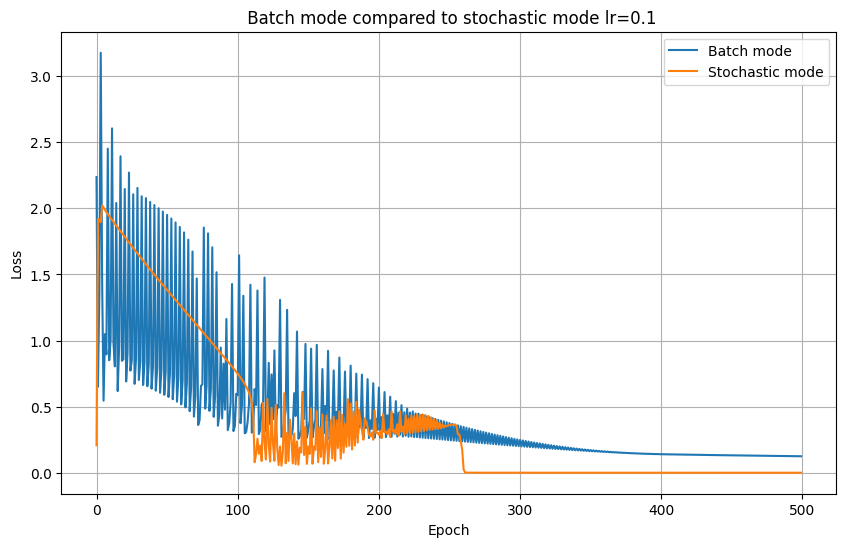

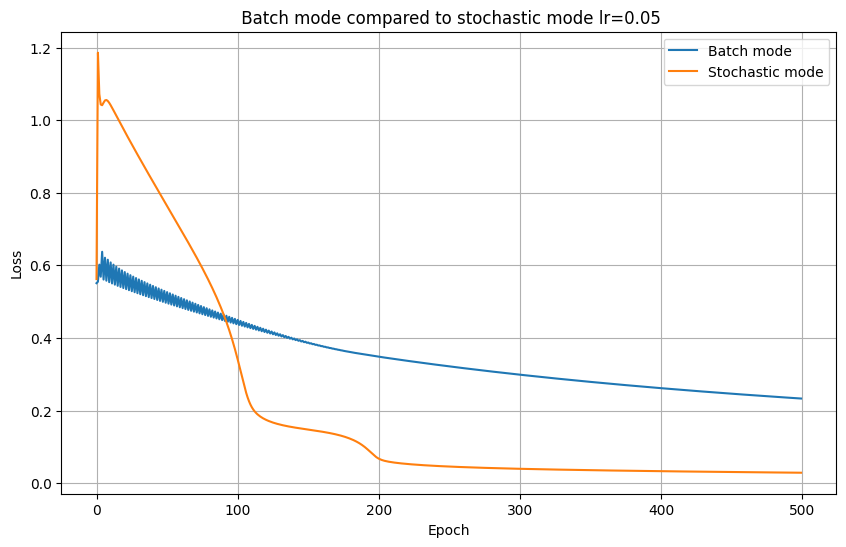

In [ ]:
def logistic_model(lr, epochs=500, mode='batch'):
    model = th.nn.Sequential(th.nn.Linear(2, 1), th.nn.Sigmoid())
    optimizer = th.optim.SGD(model.parameters(), lr=lr)
    loss_function = th.nn.BCELoss()
    losses = []

    for epoch in range(epochs):
        if mode == 'batch':
            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_function(y_pred, Y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        elif mode == 'stochastic':
            loss_stoch = 0
            for i in range(X.shape[0]):
                x = X[i].unsqueeze(0)
                y = Y[i].unsqueeze(0)

                optimizer.zero_grad()
                y_pred = model(x)
                loss = loss_function(y_pred, y)
                loss.backward()
                optimizer.step()
                loss_stoch += loss.item()

            losses.append(loss_stoch / X.shape[0])

    return losses, model

# Batch mode lr=0.1
losses_batch, model_batch = logistic_model(lr=0.1, epochs=500, mode='batch')

# Stochastic mode lr=0.1
losses_stoch, model_stoch = logistic_model(lr=0.1, epochs=500, mode='stochastic')


plt.figure(figsize=(10, 6))
plt.plot(losses_batch, label='Batch mode')
plt.plot(losses_stoch, label='Stochastic mode')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(' Batch mode compared to stochastic mode lr=0.1')
plt.legend()
plt.grid(True)
plt.show()

# Batch mode lr=0.05
losses_batch2, model_batch2 = logistic_model(lr=0.05, epochs=500, mode='batch')

# Stochastic mode lr=0.05
losses_stoch2, model_stoch2 = logistic_model(lr=0.05, epochs=500, mode='stochastic')


plt.figure(figsize=(10, 6))
plt.plot(losses_batch2, label='Batch mode')
plt.plot(losses_stoch2, label='Stochastic mode')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(' Batch mode compared to stochastic mode lr=0.05')
plt.legend()
plt.grid(True)
plt.show()

Here, we notice that stochastic mode converges toward zero loss more quickly than batch mode.
The stochastic loss curve appears smoother, especially at the beginning of training. This is likely because we log the average of the individual losses at each epoch, which smooths the curve.

In batch mode, we log the raw loss value, which is more sensitive to variations when a relatively high learning rate is used. The curve becomes smoother when using a lower learning rate, such as $lr = 0.05$.

However, stochastic mode is generally less stable than batch mode provided that the same loss metric is used for comparison and that a well-chosen learning rate is applied. For example, with a rate of $0.05$, we can already observe a noticeable drop at the beginning of the training.